In [ ]:
!pip install kaggle

In [ ]:
!kaggle datasets download -d shashwatwork/web-page-phishing-detection-dataset

Dataset URL: https://www.kaggle.com/datasets/shashwatwork/web-page-phishing-detection-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
  0% 0.00/1.01M [00:00<?, ?B/s]
100% 1.01M/1.01M [00:00<00:00, 80.1MB/s]


In [ ]:
from google.colab import files
uploaded = files.upload()  # This will open a file dialog to upload 'kaggle.json'

Saving kaggle (1).json to kaggle (1).json


In [ ]:
!unzip web-page-phishing-detection-dataset.zip


Archive:  web-page-phishing-detection-dataset.zip
  inflating: dataset_phishing.csv    


In [ ]:
!pip install lightgbm
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score
!pip install dask


/usr/local/lib/python3.10/dist-packages/dask/dataframe/__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [ ]:
# Load dataset
data = pd.read_csv('dataset_phishing.csv')  # Update path if necessary


In [ ]:
import pandas as pd

# Load dataset
data = pd.read_csv('dataset_phishing.csv')  # Update path if necessary

# Separate features and target variable
X = data.drop(columns=['status', 'url'], errors='ignore')  # Drop 'status' and 'url' if unnecessary for training
y = data['status']

# Handle missing values by filling with 0 or mean/median as appropriate
X = X.fillna(0)  # Adjust the filling strategy as per data analysis

# Encode categorical features if any exist
for col in X.select_dtypes(include=['object']).columns:
    X[col] = X[col].astype('category').cat.codes  # Converts categorical text columns to numerical codes

# At this point, X is fully preprocessed and ready for model training
print("Preprocessing complete. Here are the first few rows of the preprocessed data:")
print(X.head())


Preprocessing complete. Here are the first few rows of the preprocessed data:
   length_url  length_hostname  ip  nb_dots  nb_hyphens  nb_at  nb_qm  nb_and  \
0          37               19   0        3           0      0      0       0   
1          77               23   1        1           0      0      0       0   
2         126               50   1        4           1      0      1       2   
3          18               11   0        2           0      0      0       0   
4          55               15   0        2           2      0      0       0   

   nb_or  nb_eq  ...  empty_title  domain_in_title  domain_with_copyright  \
0      0      0  ...            0                0                      1   
1      0      0  ...            0                1                      0   
2      0      3  ...            0                1                      0   
3      0      0  ...            0                1                      0   
4      0      0  ...            0                0

In [ ]:
import pandas as pd
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.preprocessing import LabelEncoder
import joblib

# Load dataset
data = pd.read_csv('dataset_phishing.csv')  # Update the filename as needed

# Preprocessing
X = data.drop(columns=['status', 'url'], errors='ignore')  # Drop 'status' and 'url'
y = data['status']

# Encode the target variable if it's not already numeric
if y.dtype == 'object':
    le = LabelEncoder()
    y = le.fit_transform(y)  # Converts categorical labels to integers

X = X.fillna(0)  # Handle missing values

# Encode categorical features
for col in X.select_dtypes(include=['object']).columns:
    X[col] = X[col].astype('category').cat.codes  # Convert categorical to numerical codes

# Step 1: Split Data into Train and Test Sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: Train the LightGBM Model
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test)

# Define parameters for LightGBM
params = {
    'objective': 'binary',
    'metric': 'binary_logloss',
    'boosting_type': 'gbdt',
    'verbose': -1
}

# Train the model with early stopping
model = lgb.train(
    params,
    train_data,
    valid_sets=[test_data],
    num_boost_round=100,
    valid_names=['valid'],
    callbacks=[lgb.early_stopping(10)]  # Stop if validation score doesn't improve for 10 rounds
)

# Step 3: Evaluate Model
y_pred = model.predict(X_test)
y_pred = [1 if x > 0.5 else 0 for x in y_pred]  # Convert probabilities to binary outcomes

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")

# Optional: Save the model
joblib.dump(model, 'lightgbm_phishing_model.pkl')


Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[100]	valid's binary_logloss: 0.078274
Accuracy: 0.9711286089238845
Precision: 0.970770593445527
Recall: 0.970770593445527


['lightgbm_phishing_model.pkl']

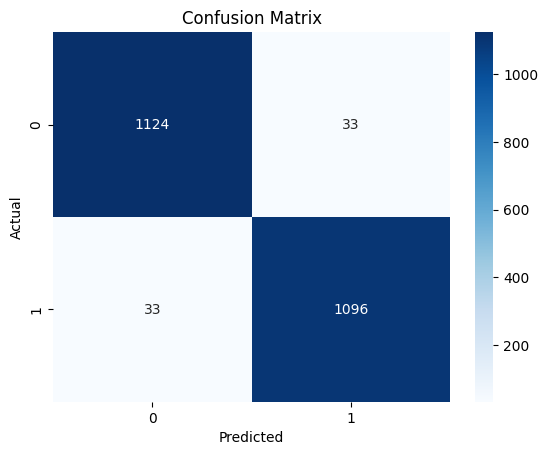

              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1157
           1       0.97      0.97      0.97      1129

    accuracy                           0.97      2286
   macro avg       0.97      0.97      0.97      2286
weighted avg       0.97      0.97      0.97      2286



In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Generate predictions
y_pred = model.predict(X_test)
y_pred = [1 if x > 0.5 else 0 for x in y_pred]

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Classification Report
print(classification_report(y_test, y_pred))


In [ ]:
import pandas as pd
import lightgbm as lgb
from urllib.parse import urlparse
import os
from datetime import datetime

# Assuming the model is already loaded as 'model'

# Define the log file path
log_file = "feedback_log.csv"

# Check if log file exists; if not, create it with headers
if not os.path.isfile(log_file):
    with open(log_file, 'w') as f:
        f.write("timestamp,url,predicted_result,correct\n")

def extract_features(url):
    # Check if the URL is valid
    if not url or not isinstance(url, str):
        return None  # or return an empty DataFrame with the correct feature columns

    parsed_url = urlparse(url)
    domain = parsed_url.hostname if parsed_url.hostname else ''

    # Calculate features
    features = {
        'length_url': len(url),
        'length_hostname': len(domain),
        'ip': 0,  # Placeholder for IP check
        'nb_dots': url.count('.'),
        'nb_hyphens': url.count('-'),
        'nb_at': url.count('@'),
        'nb_qm': url.count('?'),
        'nb_and': url.count('&'),
        'nb_or': url.count('|'),
        'nb_eq': url.count('='),
        'nb_underscore': url.count('_'),
        'nb_tilde': url.count('~'),
        'nb_percent': url.count('%'),
        'nb_slash': url.count('/'),
        'nb_star': url.count('*'),
        'nb_colon': url.count(':'),
        'nb_comma': url.count(','),
        'nb_semicolumn': url.count(';'),
        'nb_dollar': url.count('$'),
        'nb_space': url.count(' '),
        'nb_www': domain.count('www.'),
        'nb_com': url.count('.com'),
        'nb_dslash': url.count('//'),
        'http_in_path': 1 if 'http' in parsed_url.path else 0,
        'https_token': 1 if 'https' in parsed_url.path else 0,
        'ratio_digits_url': sum(c.isdigit() for c in url) / len(url) if url else 0,
        'ratio_digits_host': sum(c.isdigit() for c in domain) / len(domain) if domain else 0,
        'punycode': 0,  # Placeholder for Punycode check
        'port': parsed_url.port if parsed_url.port else 0,
        'tld_in_path': 1 if domain in parsed_url.path else 0,
        'tld_in_subdomain': 0,  # Placeholder for TLD in subdomain
        'abnormal_subdomain': 0,  # Placeholder for abnormal subdomain check
        'nb_subdomains': len(domain.split('.')) - 1,
        'prefix_suffix': 0,  # Placeholder for prefix/suffix check
        'random_domain': 0,  # Placeholder for random domain check
        'shortening_service': 0,  # Placeholder for shortening service check
        'path_extension': 0,  # Placeholder for path extension check
        'nb_redirection': 0,  # Placeholder for redirection check
        'nb_external_redirection': 0,  # Placeholder for external redirection check
        'length_words_raw': 0,  # Placeholder for length of words check
        'char_repeat': 0,  # Placeholder for character repeat check
        'shortest_words_raw': 0,  # Placeholder for shortest words check
        'shortest_word_host': 0,  # Placeholder for shortest word in host
        'shortest_word_path': 0,  # Placeholder for shortest word in path
        'longest_words_raw': 0,  # Placeholder for longest words check
        'longest_word_host': 0,  # Placeholder for longest word in host
        'longest_word_path': 0,  # Placeholder for longest word in path
        'avg_words_raw': 0,  # Placeholder for average words check
        'avg_word_host': 0,  # Placeholder for average word in host
        'avg_word_path': 0,  # Placeholder for average word in path
        'phish_hints': 0,  # Placeholder for phishing hints check
        'domain_in_brand': 0,  # Placeholder for domain in brand check
        'brand_in_subdomain': 0,  # Placeholder for brand in subdomain check
        'brand_in_path': 0,  # Placeholder for brand in path check
        'suspecious_tld': 0,  # Placeholder for suspicious TLD check
        'statistical_report': 0,  # Placeholder for statistical report check
        'nb_hyperlinks': 0,  # Placeholder for number of hyperlinks
        'ratio_intHyperlinks': 0,  # Placeholder for ratio of internal hyperlinks
        'ratio_extHyperlinks': 0,  # Placeholder for ratio of external hyperlinks
        'ratio_nullHyperlinks': 0,  # Placeholder for ratio of null hyperlinks
        'nb_extCSS': 0,  # Placeholder for number of external CSS
        'ratio_intRedirection': 0,  # Placeholder for ratio of internal redirection
        'ratio_extRedirection': 0,  # Placeholder for ratio of external redirection
        'ratio_intErrors': 0,  # Placeholder for ratio of internal errors
        'ratio_extErrors': 0,  # Placeholder for ratio of external errors
        'login_form': 0,  # Placeholder for login form check
        'external_favicon': 0,  # Placeholder for external favicon check
        'links_in_tags': 0,  # Placeholder for links in tags check
        'submit_email': 0,  # Placeholder for email submission check
        'ratio_intMedia': 0,  # Placeholder for ratio of internal media
        'ratio_extMedia': 0,  # Placeholder for ratio of external media
        'sfh': 0,  # Placeholder for server form handler check
        'iframe': 0,  # Placeholder for iframe check
        'popup_window': 0,  # Placeholder for popup window check
        'safe_anchor': 0,  # Placeholder for safe anchor check
        'onmouseover': 0,  # Placeholder for onmouseover check
        'right_clic': 0,  # Placeholder for right-click check
        'empty_title': 0,  # Placeholder for empty title check
        'domain_in_title': 0,  # Placeholder for domain in title check
        'domain_with_copyright': 0,  # Placeholder for copyright check
        'whois_registered_domain': 0,  # Placeholder for whois registration check
        'domain_registration_length': 100,  # Placeholder
        'domain_age': 100,  # Placeholder
        'web_traffic': 1000000,  # Placeholder
        'dns_record': 1,  # Placeholder
        'google_index': 1,  # Placeholder
        'page_rank': 5,  # Placeholder
    }

    return pd.DataFrame([features])

def log_feedback(url, predicted_result, correct):
    timestamp = datetime.now().isoformat()
    with open(log_file, 'a') as f:
        f.write(f"{timestamp},{url},{predicted_result},{correct}\n")

def predict_url(model, url):
    # Extract features from the URL
    features_df = extract_features(url)

    # Make a prediction
    prediction = model.predict(features_df)

    # Return the features and prediction result
    return features_df, "Phishing" if prediction[0] > 0.5 else "Legitimate"

# Main loop for user input with feedback
url_to_check = input("Enter a URL to check (or 'exit' to quit): ")

while url_to_check.lower() != 'exit':
    features, result = predict_url(model, url_to_check)
    print(f"The URL is classified as {result}. Features: {features.to_dict(orient='records')[0]}")

    # Get user feedback
    correct = input("Was this prediction correct? (yes/no): ").strip().lower()
    correct_flag = 1 if correct == 'yes' else 0

    # Log the feedback
    log_feedback(url_to_check, result, correct_flag)

    url_to_check = input("Enter a URL to check (or 'exit' to quit): ")

print("Feedback logged successfully.")


Enter a URL to check (or 'exit' to quit): www.instagram.com
The URL is classified as Phishing. Features: {'length_url': 17, 'length_hostname': 0, 'ip': 0, 'nb_dots': 2, 'nb_hyphens': 0, 'nb_at': 0, 'nb_qm': 0, 'nb_and': 0, 'nb_or': 0, 'nb_eq': 0, 'nb_underscore': 0, 'nb_tilde': 0, 'nb_percent': 0, 'nb_slash': 0, 'nb_star': 0, 'nb_colon': 0, 'nb_comma': 0, 'nb_semicolumn': 0, 'nb_dollar': 0, 'nb_space': 0, 'nb_www': 0, 'nb_com': 1, 'nb_dslash': 0, 'http_in_path': 0, 'https_token': 0, 'ratio_digits_url': 0.0, 'ratio_digits_host': 0, 'punycode': 0, 'port': 0, 'tld_in_path': 1, 'tld_in_subdomain': 0, 'abnormal_subdomain': 0, 'nb_subdomains': 0, 'prefix_suffix': 0, 'random_domain': 0, 'shortening_service': 0, 'path_extension': 0, 'nb_redirection': 0, 'nb_external_redirection': 0, 'length_words_raw': 0, 'char_repeat': 0, 'shortest_words_raw': 0, 'shortest_word_host': 0, 'shortest_word_path': 0, 'longest_words_raw': 0, 'longest_word_host': 0, 'longest_word_path': 0, 'avg_words_raw': 0, 'avg_w

KeyboardInterrupt: Interrupted by user

In [ ]:
import pandas as pd

# Load the feedback log
log_file = "feedback_log.csv"
feedback_data = pd.read_csv(log_file)

# Restructuring the DataFrame for better display
display_data = feedback_data[['timestamp', 'url', 'predicted_result', 'correct']]

# Print the nicely formatted DataFrame
print(display_data.to_string(index=False))


                 timestamp               url predicted_result  correct
2025-01-04T10:49:07.253815 www.instagram.com         Phishing        0
2025-01-04T10:49:50.581699    www.google.com         Phishing        0


In [ ]:
import pandas as pd

# Load the feedback log
log_file = 'feedback_log.csv'
feedback_data = pd.read_csv(log_file)

# Calculate total entries
total_entries = len(feedback_data)

# Calculate correct predictions
correct_count = feedback_data['correct'].sum()

# Calculate incorrect predictions
incorrect_count = total_entries - correct_count if total_entries > 0 else 0

# Print the results
print(f"Total Predictions: {total_entries}")
print(f"Correct Predictions: {correct_count}, Incorrect Predictions: {incorrect_count}")


Total Predictions: 2
Correct Predictions: 0, Incorrect Predictions: 2


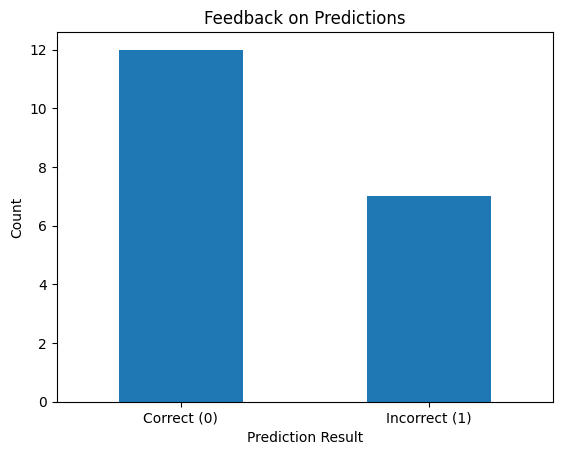

In [ ]:
import matplotlib.pyplot as plt

# Count feedback results
feedback_counts = feedback_data['correct'].value_counts()

# Plot the results
feedback_counts.plot(kind='bar')
plt.title('Feedback on Predictions')
plt.xticks(ticks=[0, 1], labels=['Correct (0)', 'Incorrect (1)'], rotation=0)
plt.xlabel('Prediction Result')
plt.ylabel('Count')
plt.show()


In [ ]:
import os

# List all files in the current directory
print("Current Directory:", os.getcwd())
print("Files in the directory:", os.listdir())


Current Directory: /content
Files in the directory: ['.config', 'lightgbm_phishing_model.pkl', 'kaggle (1).json', 'web-page-phishing-detection-dataset.zip', 'dataset_phishing.csv', 'feedback_log.csv', 'sample_data']


In [ ]:
def retrain_model():
    # Load existing data
    original_data = pd.read_csv('dataset_phishing.csv')
    feedback_data = pd.read_csv('feedback_log.csv')

    # Combine data - Assuming feedback_log contains 'url', 'predicted_result', and 'correct'
    feedback_data = feedback_data[['url', 'correct']]  # Select relevant columns
    feedback_data['status'] = feedback_data['correct'].map({1: 'Legitimate', 0: 'Phishing'})

    # You might need to merge back with the original dataset to maintain feature consistency
    combined_data = pd.concat([original_data, feedback_data], ignore_index=True)

    # Proceed with preprocessing and training as before
    # ...

# Call this function when you want to retrain
# retrain_model()


In [ ]:
import pandas as pd
import lightgbm as lgb
from urllib.parse import urlparse
import os
from datetime import datetime
import joblib  # Import joblib to load the model

# Load the trained model
model = joblib.load('/content/lightgbm_phishing_model.pkl')  # Adjust the file path if needed

# Define the log file path
log_file = "feedback_log.csv"

# Check if log file exists; if not, create it with headers
if not os.path.isfile(log_file):
    with open(log_file, 'w') as f:
        f.write("timestamp,url,predicted_result,correct\n")

def extract_features(url):
    # Check if the URL is valid
    if not url or not isinstance(url, str):
        return None  # or return an empty DataFrame with the correct feature columns

    parsed_url = urlparse(url)
    domain = parsed_url.hostname if parsed_url.hostname else ''

    # Calculate features
    features = {
        'length_url': len(url),
        'length_hostname': len(domain),
        'ip': 0,  # Placeholder for IP check
        'nb_dots': url.count('.'),
        'nb_hyphens': url.count('-'),
        'nb_at': url.count('@'),
        'nb_qm': url.count('?'),
        'nb_and': url.count('&'),
        'nb_or': url.count('|'),
        'nb_eq': url.count('='),
        'nb_underscore': url.count('_'),
        'nb_tilde': url.count('~'),
        'nb_percent': url.count('%'),
        'nb_slash': url.count('/'),
        'nb_star': url.count('*'),
        'nb_colon': url.count(':'),
        'nb_comma': url.count(','),
        'nb_semicolumn': url.count(';'),
        'nb_dollar': url.count('$'),
        'nb_space': url.count(' '),
        'nb_www': domain.count('www.'),
        'nb_com': url.count('.com'),
        'nb_dslash': url.count('//'),
        'http_in_path': 1 if 'http' in parsed_url.path else 0,
        'https_token': 1 if 'https' in parsed_url.path else 0,
        'ratio_digits_url': sum(c.isdigit() for c in url) / len(url) if url else 0,
        'ratio_digits_host': sum(c.isdigit() for c in domain) / len(domain) if domain else 0,
        'punycode': 0,  # Placeholder for Punycode check
        'port': parsed_url.port if parsed_url.port else 0,
        'tld_in_path': 1 if domain in parsed_url.path else 0,
        'tld_in_subdomain': 0,  # Placeholder for TLD in subdomain
        'abnormal_subdomain': 0,  # Placeholder for abnormal subdomain check
        'nb_subdomains': len(domain.split('.')) - 1,
        'prefix_suffix': 0,  # Placeholder for prefix/suffix check
        'random_domain': 0,  # Placeholder for random domain check
        'shortening_service': 0,  # Placeholder for shortening service check
        'path_extension': 0,  # Placeholder for path extension check
        'nb_redirection': 0,  # Placeholder for redirection check
        'nb_external_redirection': 0,  # Placeholder for external redirection check
        'length_words_raw': 0,  # Placeholder for length of words check
        'char_repeat': 0,  # Placeholder for character repeat check
        'shortest_words_raw': 0,  # Placeholder for shortest words check
        'shortest_word_host': 0,  # Placeholder for shortest word in host
        'shortest_word_path': 0,  # Placeholder for shortest word in path
        'longest_words_raw': 0,  # Placeholder for longest words check
        'longest_word_host': 0,  # Placeholder for longest word in host
        'longest_word_path': 0,  # Placeholder for longest word in path
        'avg_words_raw': 0,  # Placeholder for average words check
        'avg_word_host': 0,  # Placeholder for average word in host
        'avg_word_path': 0,  # Placeholder for average word in path
        'phish_hints': 0,  # Placeholder for phishing hints check
        'domain_in_brand': 0,  # Placeholder for domain in brand check
        'brand_in_subdomain': 0,  # Placeholder for brand in subdomain check
        'brand_in_path': 0,  # Placeholder for brand in path check
        'suspecious_tld': 0,  # Placeholder for suspicious TLD check
        'statistical_report': 0,  # Placeholder for statistical report check
        'nb_hyperlinks': 0,  # Placeholder for number of hyperlinks
        'ratio_intHyperlinks': 0,  # Placeholder for ratio of internal hyperlinks
        'ratio_extHyperlinks': 0,  # Placeholder for ratio of external hyperlinks
        'ratio_nullHyperlinks': 0,  # Placeholder for ratio of null hyperlinks
        'nb_extCSS': 0,  # Placeholder for number of external CSS
        'ratio_intRedirection': 0,  # Placeholder for ratio of internal redirection
        'ratio_extRedirection': 0,  # Placeholder for ratio of external redirection
        'ratio_intErrors': 0,  # Placeholder for ratio of internal errors
        'ratio_extErrors': 0,  # Placeholder for ratio of external errors
        'login_form': 0,  # Placeholder for login form check
        'external_favicon': 0,  # Placeholder for external favicon check
        'links_in_tags': 0,  # Placeholder for links in tags check
        'submit_email': 0,  # Placeholder for email submission check
        'ratio_intMedia': 0,  # Placeholder for ratio of internal media
        'ratio_extMedia': 0,  # Placeholder for ratio of external media
        'sfh': 0,  # Placeholder for server form handler check
        'iframe': 0,  # Placeholder for iframe check
        'popup_window': 0,  # Placeholder for popup window check
        'safe_anchor': 0,  # Placeholder for safe anchor check
        'onmouseover': 0,  # Placeholder for onmouseover check
        'right_clic': 0,  # Placeholder for right-click check
        'empty_title': 0,  # Placeholder for empty title check
        'domain_in_title': 0,  # Placeholder for domain in title check
        'domain_with_copyright': 0,  # Placeholder for copyright check
        'whois_registered_domain': 0,  # Placeholder for whois registration check
        'domain_registration_length': 100,  # Placeholder
        'domain_age': 100,  # Placeholder
        'web_traffic': 1000000,  # Placeholder
        'dns_record': 1,  # Placeholder
        'google_index': 1,  # Placeholder
        'page_rank': 5,  # Placeholder
    }

    return pd.DataFrame([features])

def log_feedback(url, predicted_result, correct):
    timestamp = datetime.now().isoformat()
    with open(log_file, 'a') as f:
        f.write(f"{timestamp},{url},{predicted_result},{correct}\n")

def predict_url(model, url):
    # Extract features from the URL
    features_df = extract_features(url)

    # Make a prediction
    prediction = model.predict(features_df)

    # Return the features and prediction result
    return features_df, "Phishing" if prediction[0] > 0.5 else "Legitimate"

# Main loop for user input with feedback
url_to_check = input("Enter a URL to check (or 'exit' to quit): ")

while url_to_check.lower() != 'exit':
    features, result = predict_url(model, url_to_check)
    print(f"The URL is classified as {result}. Features: {features.to_dict(orient='records')[0]}")

    # Get user feedback
    correct = input("Was this prediction correct? (yes/no): ").strip().lower()
    correct_flag = 1 if correct == 'yes' else 0

    # Log the feedback
    log_feedback(url_to_check, result, correct_flag)

    url_to_check = input("Enter a URL to check (or 'exit' to quit): ")

print("Feedback logged successfully.")


Enter a URL to check (or 'exit' to quit): https://www.google.com/maps
The URL is classified as Legitimate. Features: {'length_url': 27, 'length_hostname': 14, 'ip': 0, 'nb_dots': 2, 'nb_hyphens': 0, 'nb_at': 0, 'nb_qm': 0, 'nb_and': 0, 'nb_or': 0, 'nb_eq': 0, 'nb_underscore': 0, 'nb_tilde': 0, 'nb_percent': 0, 'nb_slash': 3, 'nb_star': 0, 'nb_colon': 1, 'nb_comma': 0, 'nb_semicolumn': 0, 'nb_dollar': 0, 'nb_space': 0, 'nb_www': 1, 'nb_com': 1, 'nb_dslash': 1, 'http_in_path': 0, 'https_token': 0, 'ratio_digits_url': 0.0, 'ratio_digits_host': 0.0, 'punycode': 0, 'port': 0, 'tld_in_path': 0, 'tld_in_subdomain': 0, 'abnormal_subdomain': 0, 'nb_subdomains': 2, 'prefix_suffix': 0, 'random_domain': 0, 'shortening_service': 0, 'path_extension': 0, 'nb_redirection': 0, 'nb_external_redirection': 0, 'length_words_raw': 0, 'char_repeat': 0, 'shortest_words_raw': 0, 'shortest_word_host': 0, 'shortest_word_path': 0, 'longest_words_raw': 0, 'longest_word_host': 0, 'longest_word_path': 0, 'avg_words_

In [ ]:
import joblib

# Save the trained model to a file in Colab
joblib.dump(model, '/content/lightgbm_phishing_model.joblib')


['/content/lightgbm_phishing_model.joblib']

In [ ]:
from google.colab import files

# Download the saved model file
files.download('/content/lightgbm_phishing_model.joblib')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>